# Curation of combined OXR data from Chembl.

The purpose of this notebook is to curate affinity data from Chembl. The data was already retrieved and a basic clean done (only '=' records, etc.) but as this combines data from two targets (OXR1 and 2) and has multiple readouts (IC50 and EC50), some light curation before model training is needed. The aim is to build a basic affinity model to be used in transfer learning against other targets.

In [29]:
import requests
import time
import csv

import pathlib
from pathlib import Path

from collections import Counter

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image, ImageDraw, ImageFont

Protein and data variables.

In [30]:
readout = 'oxr_combined'

In [31]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

### Curate bioactivity data.

In [32]:
df = pd.read_csv(f'OXR_combined_bioactivity.csv',index_col=None)
df.head(5)

,molecule_chembl_id,target_chembl_id,target_pref_name,standard_type,standard_relation,standard_value,standard_units,assay_chembl_id,assay_type,assay_description,document_chembl_id,uniprot_id,target_pref_name.1,readout,doi,year,publication_date,smiles,pActivity
0,CHEMBL138101,CHEMBL4792,Orexin receptor type 2,IC50,=,2000.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccc(Br)cc1)C(C)(C)...,5.698970
1,CHEMBL343551,CHEMBL4792,Orexin receptor type 2,IC50,=,36.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccccc1)NC(=O)c1cc(...,7.443697
2,CHEMBL142009,CHEMBL4792,Orexin receptor type 2,IC50,=,40.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccncc1)C(C)(...,7.397940
3,CHEMBL343786,CHEMBL4792,Orexin receptor type 2,IC50,=,35.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccsc1)C(C)(C...,7.455932
4,CHEMBL139634,CHEMBL4792,Orexin receptor type 2,IC50,=,240.0,nM,CHEMBL757348,B,Inhibitory concentration against human orexin-...,CHEMBL1136503,O43614,Orexin receptor type 2,IC50,10.1016/j.bmcl.2003.08.038,2003,2003-12-01,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccnc1)C(C)(...,6.619789


In [33]:
# Keep only IC50s
filtered_df = df[df['standard_type'] == 'IC50']

Biggest group is roughly what we'd call inactive - will need to sample.

/tmp/ipykernel_21235/870575209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['pActivity'] = filtered_df['pActivity'].astype(float)


<Axes: xlabel='pActivity', ylabel='Count'>

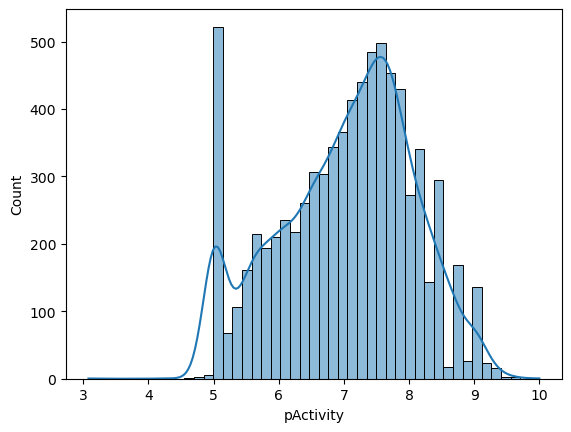

In [34]:
filtered_df['pActivity'] = filtered_df['pActivity'].astype(float)
sns.histplot(data=filtered_df, x="pActivity", kde=True)

How diverse is the data?

Parsed 7669 valid molecules out of 7688 records (99.8%).


[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerator
[13:09:07] DEPRECATION WARNING: please use MorganGenerat

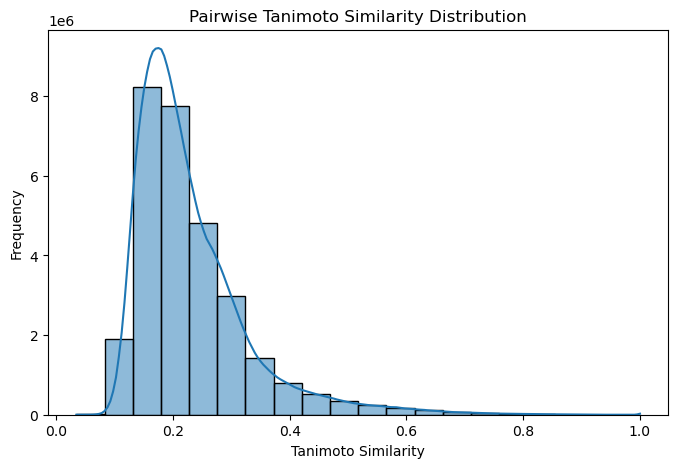

Number of molecule pairs: 29402946
Mean similarity: 0.231
Median similarity: 0.206
Max similarity: 1.000
Min similarity: 0.034


In [36]:
# Get rid of None SMILES
valid_smiles = [sm for sm in filtered_df.smiles.dropna() if isinstance(sm, str) and sm.strip()]
mols = []
for sm in valid_smiles:
    mol = Chem.MolFromSmiles(sm)
    if mol is not None:
        mols.append(mol)

print(f"Parsed {len(mols)} valid molecules out of {len(filtered_df)} records ({len(mols)/len(filtered_df)*100:.1f}%).")

if len(mols) < 2:
    raise ValueError("Not enough valid molecules to compute similarity.")

fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=1024) for m in mols]

# Pairwise similarities
similarities = []
num_mols = len(fps)
for i in range(num_mols):
    for j in range(i+1, num_mols):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        similarities.append(sim)

plt.figure(figsize=(8,5))
sns.histplot(similarities, bins=20, kde=True)
plt.title("Pairwise Tanimoto Similarity Distribution")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.savefig('_images/pairwise_tanimoto_similarity.png')
plt.show()

print(f"Number of molecule pairs: {len(similarities)}")
print(f"Mean similarity: {np.mean(similarities):.3f}")
print(f"Median similarity: {np.median(similarities):.3f}")
print(f"Max similarity: {np.max(similarities):.3f}")
print(f"Min similarity: {np.min(similarities):.3f}")

Almost no molecular similarity - good. 

How about chemical space visualisation with tSNE?

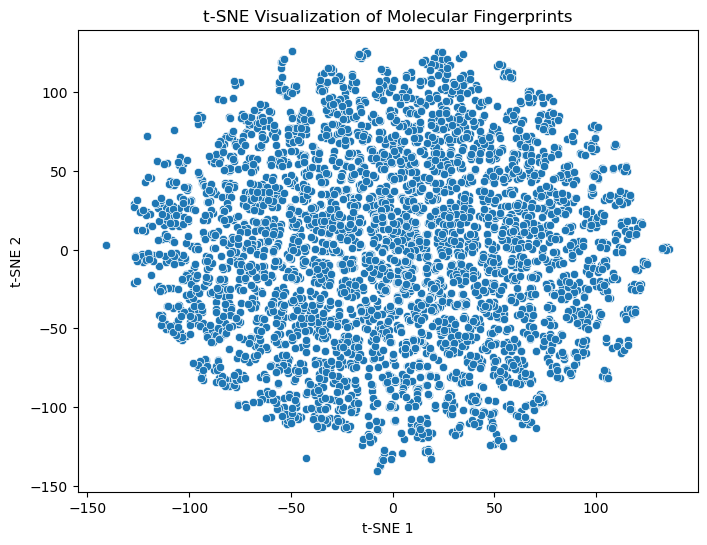

In [37]:
from sklearn.manifold import TSNE
import pandas as pd

# Use the same fingerprints from above, convert to numpy arrays
def fp_to_array(fp):
    arr = np.zeros((1,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_arrays = np.array([fp_to_array(fp) for fp in fps])

# Run t-SNE to reduce fingerprint dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
fp_tsne = tsne.fit_transform(fp_arrays)

# Plot t-SNE embedding
plt.figure(figsize=(8,6))
sns.scatterplot(x=fp_tsne[:,0], y=fp_tsne[:,1])
plt.title("t-SNE Visualization of Molecular Fingerprints")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.savefig('_images/cluster_molecule_tsne.png')
plt.show()



Number of molecules: 7669
Number of unique scaffolds: 1139
Scaffold diversity ratio: 0.149

Top 10 most frequent scaffolds:
O=C(c1ccccc1-n1nccn1)N1CCC[C@H]1c1nc(-c2ccccc2)no1: 332
O=C(c1ccccc1-n1nccn1)N1CCCC1c1nc2ccccc2[nH]1: 296
O=C(c1ncsc1-c1ccccc1)N1CCC[C@H]1c1nc2ccccc2[nH]1: 270
O=C(c1ccccc1-c1ccccc1)N1CCCC1c1nc2ccccc2[nH]1: 219
O=C(c1ccccc1-n1nccn1)N1CCC[C@H]1c1nc2ccccc2[nH]1: 210
O=C(c1ccccc1-n1nccn1)N1CCC[C@H]1c1noc(-c2ccccc2)n1: 204
O=C(c1ccccc1-n1nccn1)N1CCC[C@@H](Oc2ccccn2)C1: 202
O=C(c1ccccc1-n1nccn1)N1CCOC[C@H]1Cc1cccc(-n2nccn2)c1: 190
O=C(c1ncsc1-c1ccccc1)N1CCCC1c1nc2ccccc2[nH]1: 174
C=C1C[C@@H](c2nc3ccccc3[nH]2)N(C(=O)c2ccccc2-n2nccn2)C1: 127


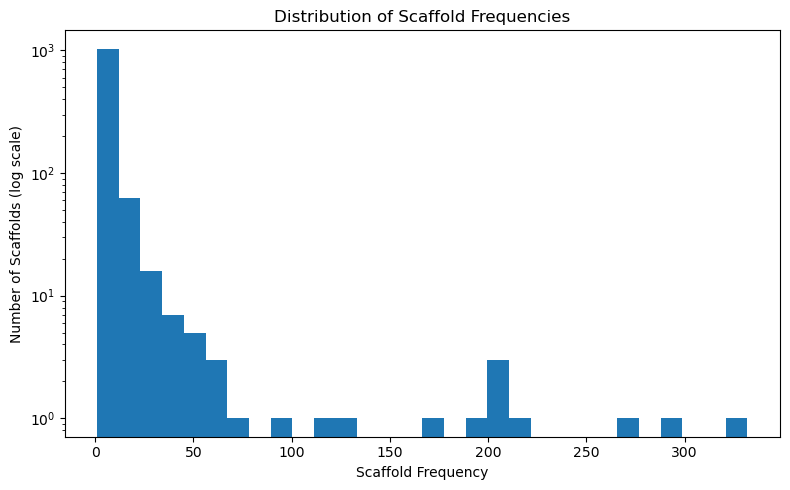

In [38]:
scaffold_smiles = []

for i, mol in enumerate(mols):
    if mol is None:
        continue
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        if scaffold is None:
            continue
        smi = Chem.MolToSmiles(scaffold)
        if smi:  # avoid empty strings
            scaffold_smiles.append(smi)
    except Exception as e:
        # print(f"Skipping molecule {i} due to error: {e}")
        continue

scaffold_counts = Counter(scaffold_smiles)

num_molecules = len([m for m in mols if m is not None])
num_unique_scaffolds = len(scaffold_counts)
scaffold_diversity_ratio = num_unique_scaffolds / num_molecules

print(f"Number of molecules: {num_molecules}")
print(f"Number of unique scaffolds: {num_unique_scaffolds}")
print(f"Scaffold diversity ratio: {scaffold_diversity_ratio:.3f}")

# Print top 10 most common scaffolds
print("\nTop 10 most frequent scaffolds:")
for scaffold, count in scaffold_counts.most_common(10):
    print(f"{scaffold}: {count}")

# Plot frequency distribution
counts = list(scaffold_counts.values())
plt.figure(figsize=(8,5))
plt.hist(counts, bins=30, log=True)
plt.xlabel("Scaffold Frequency")
plt.ylabel("Number of Scaffolds (log scale)")
plt.title("Distribution of Scaffold Frequencies")
plt.tight_layout()
plt.savefig("_images/scaffold_freq.png")
plt.show()


[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerator
[13:11:17] DEPRECATION WARNING: please use MorganGenerat

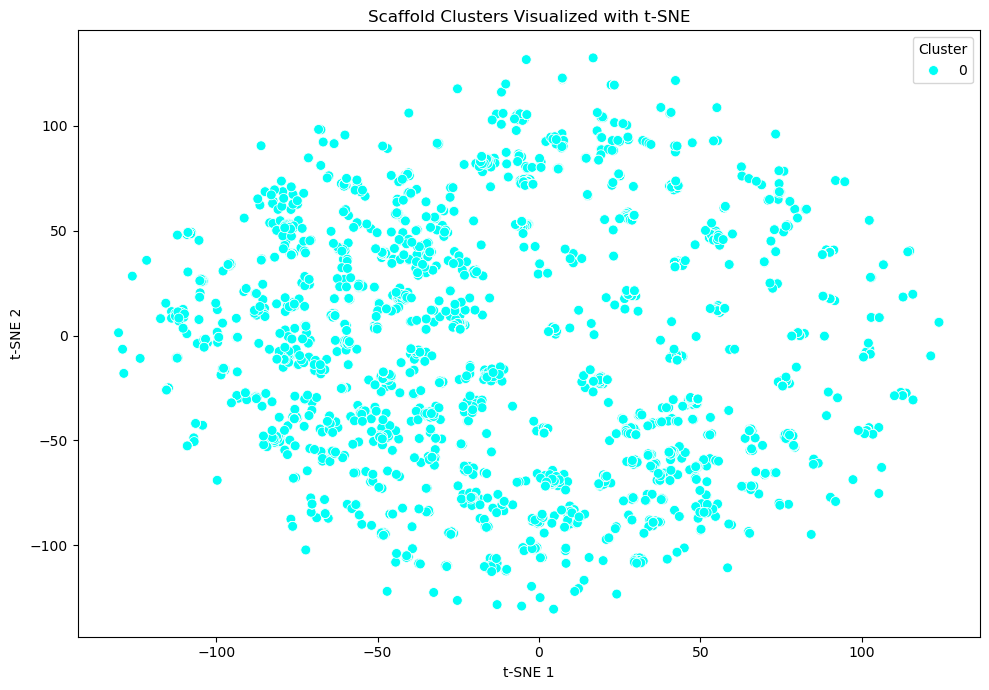

In [39]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from sklearn.cluster import AgglomerativeClustering

scaffold_fps = []
for smi in scaffold_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    scaffold_fps.append(fp)

def fp_to_array(fp):
    arr = np.zeros((1,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

scaffold_fp_arrays = np.array([fp_to_array(fp) for fp in scaffold_fps])

cluster_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=20.0,  # Adjust based on your data scale
    metric='euclidean',
    linkage='average'
)
cluster_labels = cluster_model.fit_predict(scaffold_fp_arrays)

tsne = TSNE(n_components=2, random_state=42, perplexity=10)
scaffold_tsne = tsne.fit_transform(scaffold_fp_arrays)

plt.figure(figsize=(10,7))
palette = sns.color_palette("hsv", len(np.unique(cluster_labels)))
sns.scatterplot(
    x=scaffold_tsne[:,0], y=scaffold_tsne[:,1],
    hue=cluster_labels, palette=palette, legend='full', s=50
)
plt.title("Scaffold Clusters Visualized with t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('_images/cluster_scaffold_tsne.png')
plt.show()


Hmm, not a lot of scaffold diversity in the top-10 scaffolds. That said, relative to the size of the dataset, probably not a huge problem. Sampling should solve it.

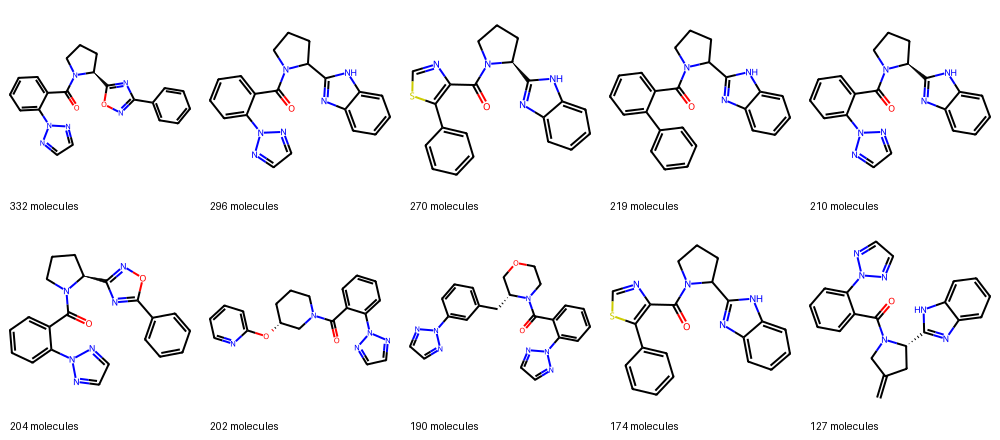

In [40]:
top_n = 10

top_scaffolds = scaffold_counts.most_common(top_n)
scaffold_mols = [Chem.MolFromSmiles(smi) for smi, _ in top_scaffolds]
scaffold_labels = [f"{count} molecules" for _, count in top_scaffolds]

mol_size = (200, 200)
images = [Draw.MolToImage(mol, size=mol_size) for mol in scaffold_mols]

def add_label(img, label, size=(200, 220)):
    new_img = Image.new("RGB", size, "white")
    new_img.paste(img, (0, 0))
    draw = ImageDraw.Draw(new_img)
    draw.text((10, 200), label, fill="black") 
    return new_img

labeled_images = [add_label(img, label) for img, label in zip(images, scaffold_labels)]

cols = 5
rows = (len(labeled_images) + cols - 1) // cols
grid_width = mol_size[0] * cols
grid_height = 220 * rows 

grid_img = Image.new("RGB", (grid_width, grid_height), "white")

for idx, img in enumerate(labeled_images):
    x = (idx % cols) * mol_size[0]
    y = (idx // cols) * 220
    grid_img.paste(img, (x, y))

grid_img.save("_images/top_10_scaffolds.png")
display(grid_img)

In [41]:
# Dump to file.

filtered_df.to_csv(DATA / f"{readout}_chembl.csv")